# Liquidity Supply Model — Simplest Specification

**Research question:** Does unpredictable LP entry compress per-capita fee revenue in the HDRN/USDC Uniswap V3 pool?

**Specification:** Two-step structural econometric model (see `notes/structural-econometrcics/specs/2026-03-02-hdrn-usdc-competition-risk.md`).

- **Step 1:** Entry predictability regression — decompose liquidity growth into predictable and unpredictable components
- **Step 2:** Fee-share impact regression — test whether unpredictable entry compresses fee share
- **Step 3:** Economic magnitude — variance decomposition

**Data:** Hourly observations from Uniswap V3 subgraph (Feb 2022 — Mar 2026).

**Unit of observation:** Hourly. Liquidity and feeGrowthGlobal are snapshotted per-hour by the subgraph (PoolHourData). Swap-level data (volume, gas, price) is aggregated to hourly. Using swap-level granularity would produce 86% zero-valued observations (multiple swaps within the same hour see the same hourly snapshot).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox

plt.style.use('classic')
plt.rcParams.update({
    'figure.figsize': (10, 4),
    'font.size': 9,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

In [2]:
# Load swap-level observations and aggregate to hourly
df_raw = pd.read_csv('../data/hdrn_usdc/observations.csv')
df_raw['datetime'] = pd.to_datetime(df_raw['timestamp'], unit='s', utc=True)
df_raw = df_raw.sort_values('timestamp').reset_index(drop=True)
print(f'Raw swap observations: {len(df_raw):,}')

# --- Aggregate to hourly ---
# Each hour gets: sum(volume), mean(gas), first-to-last price change,
# and the hourly liquidity/feeGrowth snapshot (same for all swaps in the hour).
df_raw['hour'] = df_raw['timestamp'] // 3600

hourly_agg = df_raw.groupby('hour').agg(
    timestamp=('timestamp', 'first'),
    volume_n=('volume_n', 'sum'),         # total hourly volume (USD)
    gas_n=('gas_n', 'mean'),              # mean gas price in the hour
    dp_n=('dp_n', 'sum'),                 # cumulative log price change in the hour
    tick_n=('tick_n', 'last'),            # end-of-hour tick
    l_active_n=('l_active_n', 'first'),   # hourly snapshot (same for all swaps)
    fee_growth0=('fee_growth0', 'first'), # hourly snapshot
    fee_growth1=('fee_growth1', 'first'), # hourly snapshot
    n_swaps=('swap_id', 'count'),         # swap count for diagnostics
).reset_index(drop=True)

hourly_agg['datetime'] = pd.to_datetime(hourly_agg['timestamp'], unit='s', utc=True)

# Compute hourly deltas (now consecutive rows are distinct hours)
Q128 = 2**128
UINT256_MAX = 2**256

fg0 = hourly_agg['fee_growth0'].values.astype(object)
fg1 = hourly_agg['fee_growth1'].values.astype(object)

# pi_n: fee per unit liquidity in this hour
pi_n = np.zeros(len(hourly_agg))
for i in range(1, len(hourly_agg)):
    d0 = float((fg0[i] - fg0[i-1]) % UINT256_MAX) / Q128
    d1 = float((fg1[i] - fg1[i-1]) % UINT256_MAX) / Q128
    pi_n[i] = d0 + d1
hourly_agg['pi_n'] = pi_n

# dlog_l: log liquidity growth between hours
l = hourly_agg['l_active_n'].values.astype(float)
dlog_l = np.zeros(len(hourly_agg))
for i in range(1, len(hourly_agg)):
    if l[i] > 0 and l[i-1] > 0:
        dlog_l[i] = np.log(l[i]) - np.log(l[i-1])
hourly_agg['dlog_l_n'] = dlog_l

# Drop first row (no predecessor)
df = hourly_agg.iloc[1:].copy().reset_index(drop=True)

print(f'Hourly observations: {len(df):,}')
print(f'Period: {df.datetime.min()} to {df.datetime.max()}')
print(f'pi_n == 0: {(df.pi_n == 0).sum()} ({100*(df.pi_n == 0).mean():.1f}%)')
print(f'dlog_l_n == 0: {(df.dlog_l_n == 0).sum()} ({100*(df.dlog_l_n == 0).mean():.1f}%)')
print(f'\nHourly variable summary:')
df[['pi_n', 'l_active_n', 'dlog_l_n', 'volume_n', 'gas_n', 'dp_n', 'n_swaps']].describe()

Raw swap observations: 82,799
Hourly observations: 11,825
Period: 2022-02-26 09:01:34+00:00 to 2026-03-02 06:10:35+00:00
pi_n == 0: 255 (2.2%)
dlog_l_n == 0: 7786 (65.8%)

Hourly variable summary:


,pi_n,l_active_n,dlog_l_n,volume_n,gas_n,dp_n,n_swaps
count,11825.000000,1.182500e+04,11825.000000,1.182500e+04,11825.000000,11825.000000,11825.000000
mean,42.160109,5.907232e+16,-0.000287,3.249975e+04,32.485093,-0.000442,7.001268
std,1007.787830,5.913920e+16,0.485222,9.605310e+04,42.141342,0.148976,11.951006
min,0.000000,2.153377e+12,-7.634454,0.000000e+00,0.018768,-3.435491,1.000000
25%,0.000580,1.503701e+16,0.000000,1.501604e+03,14.318180,-0.007928,2.000000
50%,0.483282,4.781817e+16,0.000000,7.034728e+03,23.345287,0.000128,3.000000
75%,2.880278,9.519959e+16,0.000000,2.566528e+04,38.673428,0.007980,7.000000
max,98753.525187,8.299244e+17,7.634454,2.622185e+06,1505.204681,4.083002,266.000000


## 1. Variable Scaling & Construction

### Scaling decisions

| Variable | Raw units | Scaling | Rationale |
|----------|-----------|---------|----------|
| `pi_n` | feeGrowth delta / Q128 (hourly) | Normalize to `pi_n / pi_bar` (rolling mean) | Remove level effects, isolate deviations |
| `l_active_n` | Raw liquidity (uint128) | Already differenced as `dlog_l_n` | Log-difference is scale-free |
| `volume_n` | USD (hourly sum) | `ln(1 + volume_n)` for log-linear; raw for linear | Right-skewed, log stabilizes variance |
| `gas_n` | Gwei (hourly mean) | `ln(gas_n)` for log-linear; Gwei for linear | Heavy right tail (pre-EIP-1559 spikes) |
| `dp_n` | log price change (hourly sum) | Used as-is | Already in log-difference form |
| `dlog_l_n` | log liquidity change | Used as-is | Already in log-difference form |

### `pi_bar` window choice

Using a 24-hour rolling mean (~1 day). This is a sensitivity parameter — we test 12h and 72h in Section 7.

### Handling zeros

- `pi_n == 0` for hours with no fee accrual — these are included (they carry information: fee share was zero)
- `dlog_l_n == 0` for hours with no liquidity change — included (no entry/exit is informative)

In [3]:
# --- Variable construction ---

# pi_bar: rolling mean of pi_n (24-hour window)
PI_BAR_WINDOW = 24
df['pi_bar'] = df['pi_n'].rolling(window=PI_BAR_WINDOW, min_periods=PI_BAR_WINDOW).mean()

# Normalized fee share: pi_n / pi_bar
# Guard: when pi_bar == 0, fee share is undefined
df['pi_norm'] = np.where(df['pi_bar'] > 0, df['pi_n'] / df['pi_bar'], np.nan)

# Log fee share for log-linear spec (only where pi_norm > 0)
df['ln_pi_norm'] = np.where(
    (df['pi_norm'].notna()) & (df['pi_norm'] > 0),
    np.log(df['pi_norm']),
    np.nan
)

# Lagged liquidity growth for Step 1
df['dlog_l_lag1'] = df['dlog_l_n'].shift(1)

# Log volume (for log-linear Model A)
df['ln_volume'] = np.log1p(df['volume_n'])

# Log gas (for log-linear specs)
df['ln_gas'] = np.log(df['gas_n'])

# --- Regression sample ---
# For linear: need pi_norm, dlog_l_lag1
df_lin = df.dropna(subset=['pi_norm', 'dlog_l_lag1']).copy()
df_lin = df_lin.replace([np.inf, -np.inf], np.nan).dropna(subset=['pi_norm', 'ln_gas'])

# For log-linear: additionally need pi_norm > 0 (for log)
df_log = df.dropna(subset=['ln_pi_norm', 'dlog_l_lag1']).copy()
df_log = df_log.replace([np.inf, -np.inf], np.nan).dropna(subset=['ln_pi_norm', 'ln_gas'])

# Use linear sample as primary (includes pi_norm == 0 hours)
df_reg = df_lin

print(f'Linear regression sample: {len(df_lin):,} hourly obs')
print(f'Log-linear regression sample: {len(df_log):,} hourly obs (excludes pi_norm=0 hours)')
print(f'Dropped: {len(df) - len(df_lin):,} from rolling window/NaN')
print(f'\nConstructed variable summary:')
df_reg[['pi_norm', 'dlog_l_n', 'dlog_l_lag1', 'volume_n', 'ln_volume', 'gas_n', 'ln_gas', 'dp_n']].describe()

Linear regression sample: 11,802 hourly obs
Log-linear regression sample: 11,547 hourly obs (excludes pi_norm=0 hours)
Dropped: 23 from rolling window/NaN

Constructed variable summary:


/home/jmsbpp/apps/ThetaSwap/ThetaSwap-research/uhi8/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,pi_norm,dlog_l_n,dlog_l_lag1,volume_n,ln_volume,gas_n,ln_gas,dp_n
count,11802.000000,11802.000000,11802.000000,1.180200e+04,11802.000000,11802.000000,11802.000000,11802.000000
mean,1.047190,-0.000640,-0.000635,3.250042e+04,8.425256,32.457926,3.037823,-0.000473
std,1.882244,0.485403,0.485404,9.614002e+04,2.572312,42.171242,1.147173,0.148845
min,0.000000,-7.634454,-7.634454,0.000000e+00,0.000000,0.018768,-3.975620,-3.435491
25%,0.000740,0.000000,0.000000,1.500000e+03,7.313887,14.305140,2.660619,-0.007914
50%,0.357031,0.000000,0.000000,7.011667e+03,8.855473,23.306780,3.148744,0.000128
75%,1.229063,0.000000,0.000000,2.563449e+04,10.151733,38.581877,3.652783,0.007965
max,22.911932,7.634454,7.634454,2.622185e+06,14.779519,1505.204681,7.316684,4.083002


## 2. Data Diagnostics

Before running regressions, verify:
1. Fee share variation is not dominated by a few extreme observations
2. Liquidity growth has meaningful variation (not constant)
3. No perfect collinearity among regressors

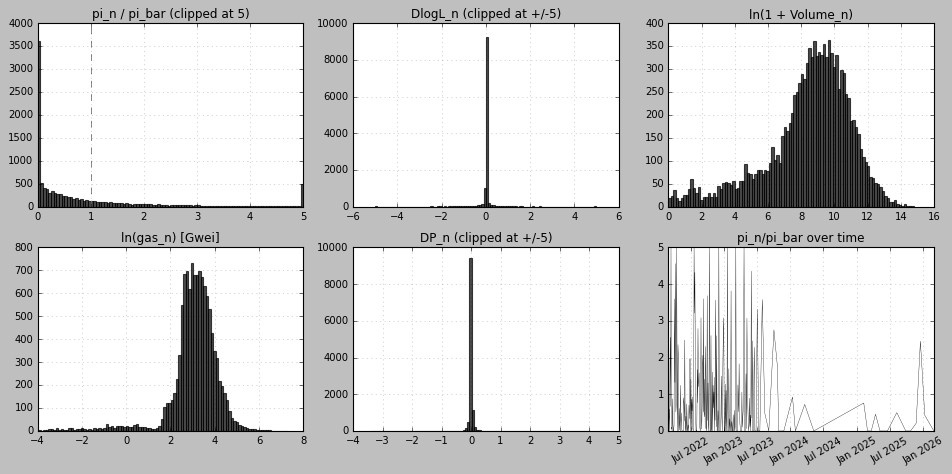


Correlation matrix (regressors):
             dlog_l_n  dlog_l_lag1   dp_n  gas_n  ln_gas  volume_n  ln_volume
dlog_l_n        1.000       -0.302  0.053  0.003  -0.006     0.001      0.003
dlog_l_lag1    -0.302        1.000 -0.004 -0.013  -0.010    -0.011      0.003
dp_n            0.053       -0.004  1.000 -0.025  -0.011     0.009      0.005
gas_n           0.003       -0.013 -0.025  1.000   0.564     0.091      0.184
ln_gas         -0.006       -0.010 -0.011  0.564   1.000     0.103      0.523
volume_n        0.001       -0.011  0.009  0.091   0.103     1.000      0.439
ln_volume       0.003        0.003  0.005  0.184   0.523     0.439      1.000


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

# pi_norm distribution
axes[0, 0].hist(df_reg['pi_norm'].clip(0, 5), bins=100, color='k', alpha=0.7)
axes[0, 0].set_title('pi_n / pi_bar (clipped at 5)')
axes[0, 0].axvline(1.0, color='gray', linestyle='--', linewidth=0.8)

# dlog_l_n distribution
axes[0, 1].hist(df_reg['dlog_l_n'].clip(-5, 5), bins=100, color='k', alpha=0.7)
axes[0, 1].set_title('DlogL_n (clipped at +/-5)')

# volume distribution (log)
axes[0, 2].hist(df_reg['ln_volume'], bins=100, color='k', alpha=0.7)
axes[0, 2].set_title('ln(1 + Volume_n)')

# gas distribution (log)
axes[1, 0].hist(df_reg['ln_gas'], bins=100, color='k', alpha=0.7)
axes[1, 0].set_title('ln(gas_n) [Gwei]')

# dp_n distribution
axes[1, 1].hist(df_reg['dp_n'].clip(-5, 5), bins=100, color='k', alpha=0.7)
axes[1, 1].set_title('DP_n (clipped at +/-5)')

# Time series of pi_norm (subsample for visibility)
sub = df_reg.iloc[::50]  # every 50th obs
axes[1, 2].plot(sub['datetime'], sub['pi_norm'].clip(0, 5), 'k-', linewidth=0.3)
axes[1, 2].set_title('pi_n/pi_bar over time')
axes[1, 2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Correlation matrix of regressors
corr_vars = ['dlog_l_n', 'dlog_l_lag1', 'dp_n', 'gas_n', 'ln_gas', 'volume_n', 'ln_volume']
print('\nCorrelation matrix (regressors):')
print(df_reg[corr_vars].corr().round(3).to_string())

## 3. Step 1 — Entry Predictability Regression

**Equation:**
$$\Delta\log L_n = \beta_0 + \beta_1 \Delta\log L_{n-1} + \beta_2 \cdot gas_n + \beta_3 \cdot \Delta P_n + u_n$$

**Purpose:** Decompose liquidity growth into predictable (fitted values) and unpredictable ($\hat{u}_n$) components. The residual $\hat{u}_n$ is the competition shock used in Step 2.

**Inference:** HAC (Newey-West) standard errors with automatic bandwidth selection. No distributional assumptions on errors.

In [5]:
# Step 1: Entry predictability regression
# DlogL_n = beta_0 + beta_1 * DlogL_{n-1} + beta_2 * gas_n + beta_3 * DP_n + u_n

y_step1 = df_reg['dlog_l_n']
X_step1 = sm.add_constant(df_reg[['dlog_l_lag1', 'gas_n', 'dp_n']])

# OLS with Newey-West HAC standard errors
# Bandwidth: Newey-West automatic (maxlags ~ N^(1/3))
nw_lags = int(np.ceil(len(y_step1) ** (1/3)))
print(f'Newey-West bandwidth: {nw_lags} lags')

model_step1 = OLS(y_step1, X_step1).fit(cov_type='HAC', cov_kwds={'maxlags': nw_lags})
print(model_step1.summary())

# Extract residuals = u_hat_n (unpredictable competition shock)
df_reg = df_reg.copy()
df_reg['u_hat'] = model_step1.resid

print(f'\nResidual u_hat summary:')
print(f'  mean: {df_reg["u_hat"].mean():.6f} (should be ~0)')
print(f'  std:  {df_reg["u_hat"].std():.6f}')
print(f'  R²:   {model_step1.rsquared:.4f}')

Newey-West bandwidth: 23 lags
                            OLS Regression Results                            
Dep. Variable:               dlog_l_n   R-squared:                       0.094
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     35.69
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           5.96e-23
Time:                        14:09:27   Log-Likelihood:                -7634.2
No. Observations:               11802   AIC:                         1.528e+04
Df Residuals:                   11798   BIC:                         1.531e+04
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.00

### Step 1 Diagnostics

Check:
1. Residual autocorrelation (Ljung-Box) — if strong, model may need more lags
2. Residual heteroskedasticity (Breusch-Pagan) — HAC SEs handle this, but good to know
3. Residual distribution — no normality required, but check for extreme outliers

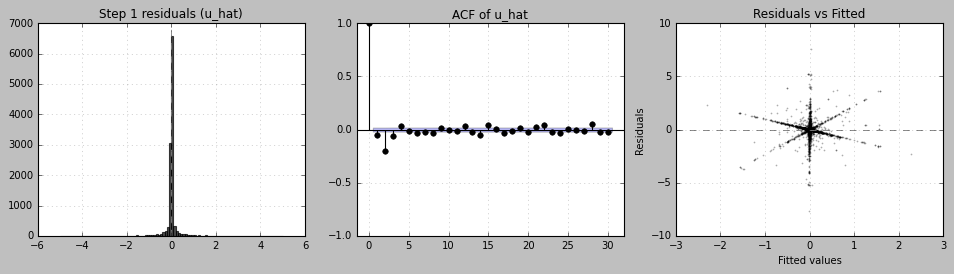

Ljung-Box test (H0: no autocorrelation):
       lb_stat      lb_pvalue
1    35.796966   2.189886e-09
2   513.083947  3.848014e-112
3   553.253840  1.369747e-119
4   565.102352  5.523508e-121
5   567.699341  1.922843e-120
6   577.247588  1.883313e-121
7   581.645624  2.180163e-121
8   595.259522  2.445118e-123
9   598.546530  4.294945e-123
10  598.546987  3.606277e-122

Breusch-Pagan test: stat=7.21, p-value=0.0656
(HAC SEs are robust to heteroskedasticity regardless)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

# Residual histogram
axes[0].hist(df_reg['u_hat'].clip(-5, 5), bins=100, color='k', alpha=0.7)
axes[0].set_title('Step 1 residuals (u_hat)')
axes[0].axvline(0, color='gray', linestyle='--', linewidth=0.8)

# ACF of residuals
sm.graphics.tsa.plot_acf(df_reg['u_hat'].values, lags=30, ax=axes[1],
                         color='k', vlines_kwargs={'color': 'k'})
axes[1].set_title('ACF of u_hat')

# Residual vs fitted
axes[2].scatter(model_step1.fittedvalues, df_reg['u_hat'], s=0.3, c='k', alpha=0.3)
axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_xlabel('Fitted values')
axes[2].set_ylabel('Residuals')
axes[2].set_title('Residuals vs Fitted')

plt.tight_layout()
plt.show()

# Ljung-Box test for residual autocorrelation
lb = acorr_ljungbox(df_reg['u_hat'], lags=10, return_df=True)
print('Ljung-Box test (H0: no autocorrelation):')
print(lb.to_string())

# Breusch-Pagan test for heteroskedasticity
bp_stat, bp_pval, _, _ = het_breuschpagan(model_step1.resid, model_step1.model.exog)
print(f'\nBreusch-Pagan test: stat={bp_stat:.2f}, p-value={bp_pval:.4f}')
print('(HAC SEs are robust to heteroskedasticity regardless)')

## 4. Step 2 — Fee-Share Impact Regression

Two models estimated:

**Model A** (volume as control):
$$\pi_n / \bar{\pi} = \alpha + \theta \hat{u}_n + \delta_1 \text{Volume}_n + \delta_2 \text{gas}_n + \varepsilon_n$$

**Model B** (perfect volume elasticity — volume drops out):
$$\pi_n / \bar{\pi} = \alpha + \theta \hat{u}_n + \delta_2 \text{gas}_n + \varepsilon_n$$

Both estimated in linear and log-linear form.

**Key coefficient:** $\theta < 0$ means unpredictable LP entry compresses fee share.

**Generated regressor note:** $\hat{u}_n$ is estimated from Step 1. Standard errors in Step 2 should be adjusted (Murphy-Topel or bootstrap). We report HAC SEs as a lower bound and note this caveat.

In [7]:
# Step 2: Fee-share impact regressions
# All with Newey-West HAC standard errors

results = {}

# --- LINEAR SPECIFICATIONS (use df_reg = df_lin, includes pi_norm=0) ---

# Model A (linear): pi_norm = alpha + theta*u_hat + delta1*volume + delta2*gas + eps
y_lin = df_reg['pi_norm']
X_A_lin = sm.add_constant(df_reg[['u_hat', 'volume_n', 'gas_n']])
results['A_linear'] = OLS(y_lin, X_A_lin).fit(cov_type='HAC', cov_kwds={'maxlags': nw_lags})

# Model B (linear): pi_norm = alpha + theta*u_hat + delta2*gas + eps
X_B_lin = sm.add_constant(df_reg[['u_hat', 'gas_n']])
results['B_linear'] = OLS(y_lin, X_B_lin).fit(cov_type='HAC', cov_kwds={'maxlags': nw_lags})

# --- LOG-LINEAR SPECIFICATIONS (use df_log, excludes pi_norm=0 hours) ---
# Need to re-run Step 1 on the log-linear subsample for consistent u_hat
y1_log = df_log['dlog_l_n']
X1_log = sm.add_constant(df_log[['dlog_l_lag1', 'gas_n', 'dp_n']])
m1_log = OLS(y1_log, X1_log).fit()
df_log = df_log.copy()
df_log['u_hat_log'] = m1_log.resid

nw_lags_log = int(np.ceil(len(df_log) ** (1/3)))

# Model A (log-linear): ln(pi_norm) = alpha + theta*u_hat + delta1*ln_volume + delta2*ln_gas + eps
y_log_dep = df_log['ln_pi_norm']
X_A_log = sm.add_constant(df_log[['u_hat_log', 'ln_volume', 'ln_gas']])
results['A_loglinear'] = OLS(y_log_dep, X_A_log).fit(cov_type='HAC', cov_kwds={'maxlags': nw_lags_log})

# Model B (log-linear): ln(pi_norm) = alpha + theta*u_hat + delta2*ln_gas + eps
X_B_log = sm.add_constant(df_log[['u_hat_log', 'ln_gas']])
results['B_loglinear'] = OLS(y_log_dep, X_B_log).fit(cov_type='HAC', cov_kwds={'maxlags': nw_lags_log})

# --- RESULTS TABLE ---
print('Step 2 Results: theta (competition shock coefficient)')
print('=' * 70)
print(f'{"Model":20s} {"theta":>10s} {"SE(HAC)":>10s} {"t-stat":>10s} {"p-value":>10s} {"R²":>8s}')
print('-' * 70)
for name, res in results.items():
    u_col = 'u_hat_log' if 'loglinear' in name else 'u_hat'
    theta = res.params[u_col]
    se = res.bse[u_col]
    t = res.tvalues[u_col]
    p = res.pvalues[u_col]
    r2 = res.rsquared
    print(f'{name:20s} {theta:>10.6f} {se:>10.6f} {t:>10.3f} {p:>10.4f} {r2:>8.4f}')
print('=' * 70)
print('\nH0: theta >= 0 (no competition effect)')
print('H1: theta < 0 (unpredictable entry compresses fee share)')

Step 2 Results: theta (competition shock coefficient)
Model                     theta    SE(HAC)     t-stat    p-value       R²
----------------------------------------------------------------------
A_linear              -0.545561   0.106865     -5.105     0.0000   0.1162
B_linear              -0.549117   0.107381     -5.114     0.0000   0.0433
A_loglinear           -1.160256   0.185983     -6.238     0.0000   0.1070
B_loglinear           -1.091465   0.187450     -5.823     0.0000   0.0110

H0: theta >= 0 (no competition effect)
H1: theta < 0 (unpredictable entry compresses fee share)


In [8]:
# Full regression tables for each specification
for name, res in results.items():
    print(f'\n{"=" * 70}')
    print(f'Model: {name}')
    print(f'{"=" * 70}')
    print(res.summary())


Model: A_linear
                            OLS Regression Results                            
Dep. Variable:                pi_norm   R-squared:                       0.116
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     31.09
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           5.20e-20
Time:                        14:09:28   Log-Likelihood:                -23481.
No. Observations:               11802   AIC:                         4.697e+04
Df Residuals:                   11798   BIC:                         4.700e+04
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6806      0.040   

## 5. Step 3 — Economic Magnitude (Variance Decomposition)

$$\text{Competition risk share} = \frac{\text{Var}(\hat{\theta} \cdot \hat{u}_n)}{\text{Var}(\pi_n / \bar{\pi})}$$

This measures what fraction of fee share variance is attributable to unpredictable competition shocks.

In [9]:
print('Variance Decomposition: Competition Risk Share')
print('=' * 60)

for name, res in results.items():
    is_log = 'loglinear' in name
    u_col = 'u_hat_log' if is_log else 'u_hat'
    sample = df_log if is_log else df_reg

    theta = res.params[u_col]

    # Variance of the competition component
    var_competition = np.var(theta * sample[u_col])

    # Variance of the dependent variable
    if is_log:
        var_y = np.var(sample['ln_pi_norm'])
    else:
        var_y = np.var(sample['pi_norm'])

    share = var_competition / var_y if var_y > 0 else 0

    print(f'{name:20s}  Var(theta*u_hat)={var_competition:.6g}  Var(y)={var_y:.6g}  Share={share:.4f} ({100*share:.2f}%)')

print('\nInterpretation: share > 5% is economically meaningful for a single risk factor.')

Variance Decomposition: Competition Risk Share
A_linear              Var(theta*u_hat)=0.0635427  Var(y)=3.54254  Share=0.0179 (1.79%)
B_linear              Var(theta*u_hat)=0.0643737  Var(y)=3.54254  Share=0.0182 (1.82%)
A_loglinear           Var(theta*u_hat)=0.277694  Var(y)=82.1288  Share=0.0034 (0.34%)
B_loglinear           Var(theta*u_hat)=0.245742  Var(y)=82.1288  Share=0.0030 (0.30%)

Interpretation: share > 5% is economically meaningful for a single risk factor.


## 6. Specification Tests

| # | Test | Mathematical statement |
|---|------|----------------------|
| 1 | Competition compresses fee share | $\theta < 0$ (one-sided t-test) |
| 2 | Competition risk is economically significant | $\text{Var}(\theta \hat{u}) / \text{Var}(y) > 0.05$ |
| 3 | Volume adds no information (Model A vs B) | LR test: $\delta_1 = 0$ |

In [10]:
from scipy import stats

print('Specification Test 1: theta < 0 (one-sided)')
print('=' * 60)
for name, res in results.items():
    u_col = 'u_hat_log' if 'loglinear' in name else 'u_hat'
    t = res.tvalues[u_col]
    # One-sided p-value (left tail: theta < 0)
    p_one_sided = stats.t.cdf(t, df=res.df_resid)
    verdict = 'REJECT H0' if p_one_sided < 0.05 else 'FAIL TO REJECT'
    print(f'{name:20s}  t={t:>8.3f}  p(one-sided)={p_one_sided:.4f}  [{verdict}]')

print(f'\nSpecification Test 3: Volume adds information? (LR test, Model A vs B)')
print('=' * 60)

for form in ['linear', 'loglinear']:
    llf_a = results[f'A_{form}'].llf
    llf_b = results[f'B_{form}'].llf
    lr_stat = 2 * (llf_a - llf_b)
    lr_pval = 1 - stats.chi2.cdf(lr_stat, df=1)  # 1 restriction
    verdict = 'Volume matters' if lr_pval < 0.05 else 'Volume drops out'
    print(f'{form:15s}  LR stat={lr_stat:>10.3f}  p-value={lr_pval:.4f}  [{verdict}]')

Specification Test 1: theta < 0 (one-sided)
A_linear              t=  -5.105  p(one-sided)=0.0000  [REJECT H0]
B_linear              t=  -5.114  p(one-sided)=0.0000  [REJECT H0]
A_loglinear           t=  -6.238  p(one-sided)=0.0000  [REJECT H0]
B_loglinear           t=  -5.823  p(one-sided)=0.0000  [REJECT H0]

Specification Test 3: Volume adds information? (LR test, Model A vs B)
linear           LR stat=   934.624  p-value=0.0000  [Volume matters]
loglinear        LR stat=  1178.180  p-value=0.0000  [Volume matters]


## 7. Sensitivity Analysis

### 7.1 pi_bar window sensitivity
Re-estimate with window = 100 and 500 to check coefficient stability.

In [11]:
print('Sensitivity: pi_bar window choice (hours)')
print('=' * 70)
print(f'{"Window(h)":>10s} {"theta(B_lin)":>14s} {"SE":>10s} {"t":>8s} {"R²":>8s} {"N":>8s}')
print('-' * 70)

for window in [12, 24, 72]:
    _df = df.copy()
    _df['pi_bar_w'] = _df['pi_n'].rolling(window=window, min_periods=window).mean()
    _df['pi_norm_w'] = np.where(_df['pi_bar_w'] > 0, _df['pi_n'] / _df['pi_bar_w'], np.nan)
    _df['dlog_l_lag1'] = _df['dlog_l_n'].shift(1)
    _df = _df.dropna(subset=['pi_norm_w', 'dlog_l_lag1']).replace([np.inf, -np.inf], np.nan).dropna(subset=['pi_norm_w'])

    # Step 1
    _y1 = _df['dlog_l_n']
    _X1 = sm.add_constant(_df[['dlog_l_lag1', 'gas_n', 'dp_n']])
    _m1 = OLS(_y1, _X1).fit()
    _df = _df.copy()
    _df['u_hat_w'] = _m1.resid

    # Step 2 Model B linear
    _y2 = _df['pi_norm_w']
    _X2 = sm.add_constant(_df[['u_hat_w', 'gas_n']])
    _nw = int(np.ceil(len(_y2) ** (1/3)))
    _m2 = OLS(_y2, _X2).fit(cov_type='HAC', cov_kwds={'maxlags': _nw})

    print(f'{window:>10d} {_m2.params["u_hat_w"]:>14.6f} {_m2.bse["u_hat_w"]:>10.6f} {_m2.tvalues["u_hat_w"]:>8.3f} {_m2.rsquared:>8.4f} {len(_df):>8,}')

Sensitivity: pi_bar window choice (hours)
 Window(h)   theta(B_lin)         SE        t       R²        N
----------------------------------------------------------------------
        12      -0.434641   0.066660   -6.520   0.0400   11,814
        24      -0.549117   0.107381   -5.114   0.0433   11,802


        72      -0.656289   0.124146   -5.286   0.0446   11,754


### 7.2 Sub-period analysis

Test coefficient stability across:
- Pre-Merge (Feb 2022 — Sep 2022): PoW, variable block times
- Post-Merge (Sep 2022 onwards): PoS, fixed 12s blocks

In [12]:
MERGE_TS = 1663224179  # Sep 15, 2022

print('Sub-period analysis: theta stability')
print('=' * 70)
print(f'{"Period":>15s} {"N":>8s} {"theta(B_lin)":>14s} {"SE(HAC)":>10s} {"t":>8s} {"p":>8s}')
print('-' * 70)

for label, mask in [('Pre-Merge', df_reg['timestamp'] < MERGE_TS),
                     ('Post-Merge', df_reg['timestamp'] >= MERGE_TS),
                     ('Full sample', pd.Series(True, index=df_reg.index))]:
    sub = df_reg[mask].copy()
    if len(sub) < 500:
        print(f'{label:>15s} {len(sub):>8,}  -- too few observations --')
        continue
    
    # Step 1 on sub-period
    _y1 = sub['dlog_l_n']
    _X1 = sm.add_constant(sub[['dlog_l_lag1', 'gas_n', 'dp_n']])
    _m1 = OLS(_y1, _X1).fit()
    sub['u_hat_sub'] = _m1.resid
    
    # Step 2 Model B linear
    _y2 = sub['pi_norm']
    _X2 = sm.add_constant(sub[['u_hat_sub', 'gas_n']])
    _nw = int(np.ceil(len(_y2) ** (1/3)))
    _m2 = OLS(_y2, _X2).fit(cov_type='HAC', cov_kwds={'maxlags': _nw})
    
    theta = _m2.params['u_hat_sub']
    se = _m2.bse['u_hat_sub']
    t = _m2.tvalues['u_hat_sub']
    p = _m2.pvalues['u_hat_sub']
    print(f'{label:>15s} {len(sub):>8,} {theta:>14.6f} {se:>10.6f} {t:>8.3f} {p:>8.4f}')

Sub-period analysis: theta stability
         Period        N   theta(B_lin)    SE(HAC)        t        p
----------------------------------------------------------------------
      Pre-Merge    4,579      -0.323951   0.121311   -2.670   0.0076
     Post-Merge    7,223      -0.549497   0.139070   -3.951   0.0001


    Full sample   11,802      -0.549117   0.107381   -5.114   0.0000


### 7.3 Reduced-form comparison

Estimate without the two-step decomposition — use raw `DlogL_n` instead of `u_hat_n`. If structural and reduced-form estimates are similar, the decomposition validates.

In [13]:
# Reduced form: pi_norm = alpha + gamma * DlogL_n + delta * gas_n + eps
y_rf = df_reg['pi_norm']
X_rf = sm.add_constant(df_reg[['dlog_l_n', 'gas_n']])
model_rf = OLS(y_rf, X_rf).fit(cov_type='HAC', cov_kwds={'maxlags': nw_lags})

print('Reduced-form comparison')
print('=' * 60)
print(f'{"Specification":20s} {"Coef(competition)":>18s} {"SE":>10s} {"t":>8s}')
print('-' * 60)
print(f'{"Structural (u_hat)":20s} {results["B_linear"].params["u_hat"]:>18.6f} {results["B_linear"].bse["u_hat"]:>10.6f} {results["B_linear"].tvalues["u_hat"]:>8.3f}')
print(f'{"Reduced-form (DlogL)":20s} {model_rf.params["dlog_l_n"]:>18.6f} {model_rf.bse["dlog_l_n"]:>10.6f} {model_rf.tvalues["dlog_l_n"]:>8.3f}')
print(f'\nIf signs agree and magnitudes are similar, the two-step decomposition is validated.')
print(f'If different, the decomposition into predictable vs unpredictable entry is empirically important.')

Reduced-form comparison
Specification         Coef(competition)         SE        t
------------------------------------------------------------
Structural (u_hat)            -0.549117   0.107381   -5.114
Reduced-form (DlogL)          -0.431660   0.093754   -4.604

If signs agree and magnitudes are similar, the two-step decomposition is validated.
If different, the decomposition into predictable vs unpredictable entry is empirically important.


## 8. Summary & Interpretation

In [14]:
# Collect key results
best = results['B_linear']
theta_hat = best.params['u_hat']
theta_se = best.bse['u_hat']
theta_t = best.tvalues['u_hat']
theta_p = best.pvalues['u_hat']

var_comp = np.var(theta_hat * df_reg['u_hat'])
var_y = np.var(df_reg['pi_norm'])
comp_share = var_comp / var_y if var_y > 0 else 0

print('Summary of Key Findings')
print('=' * 60)
print(f'Sample: {len(df_reg):,} hourly observations')
print(f'Pool: HDRN/USDC 1% (Uniswap V3)')
print(f'Period: {df_reg.datetime.min().strftime("%Y-%m-%d")} to {df_reg.datetime.max().strftime("%Y-%m-%d")}')
print()
print(f'Step 1 (Entry predictability): R² = {model_step1.rsquared:.4f}')
print(f'  -> {100*model_step1.rsquared:.1f}% of liquidity growth is predictable from lagged growth, gas, price')
print(f'  -> {100*(1-model_step1.rsquared):.1f}% is unpredictable (competition shock)')
print()
print(f'Step 2 (Fee-share impact, Model B linear):')
print(f'  theta = {theta_hat:.6f} (SE = {theta_se:.6f})')
print(f'  t-stat = {theta_t:.3f}, p-value = {theta_p:.4f}')
sign = 'NEGATIVE (competition compresses fees)' if theta_hat < 0 else 'POSITIVE (unexpected)'
print(f'  Sign: {sign}')
print()
print(f'Step 3 (Economic magnitude):')
print(f'  Competition risk share = {100*comp_share:.2f}% of fee share variance')
print(f'  Interpretation: {"Economically meaningful" if comp_share > 0.05 else "Modest effect"}')

Summary of Key Findings
Sample: 11,802 hourly observations
Pool: HDRN/USDC 1% (Uniswap V3)
Period: 2022-02-27 to 2026-03-02

Step 1 (Entry predictability): R² = 0.0938
  -> 9.4% of liquidity growth is predictable from lagged growth, gas, price
  -> 90.6% is unpredictable (competition shock)

Step 2 (Fee-share impact, Model B linear):
  theta = -0.549117 (SE = 0.107381)
  t-stat = -5.114, p-value = 0.0000
  Sign: NEGATIVE (competition compresses fees)

Step 3 (Economic magnitude):
  Competition risk share = 1.82% of fee share variance
  Interpretation: Modest effect
